# Task 2 · Gestalt principles of grouping

**Ali Afzal** · BSAI-7B-102 · Data Visualization · Week 2

The dots are almost identical in every panel, and only their arrangement changes. Any grouping you see comes
from the layout, not from the numbers.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# Paul Tol "bright" palette: stays distinct for colour-blind readers
RED, BLUE, GREY, INK = "#ee6677", "#4477aa", "#bbbbbb", "#333333"

plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})


def save(fig, name):
    fig.savefig(CHARTS / name, dpi=300, bbox_inches="tight")

from matplotlib.patches import Rectangle

In [2]:
gest = pd.read_csv(DATA / "stimuli_gestalt.csv")
TRUE_GROUPS = gest.groupby("panel").group.nunique()

gest.groupby("panel", sort=False).agg(items=("x", "size"), true_groups=("group", "nunique"))

,items,true_groups
panel,,
proximity,48,4
similarity,48,4
enclosure,48,4
continuity,48,2
closure,44,2
connection,48,24


## 1. All six panels

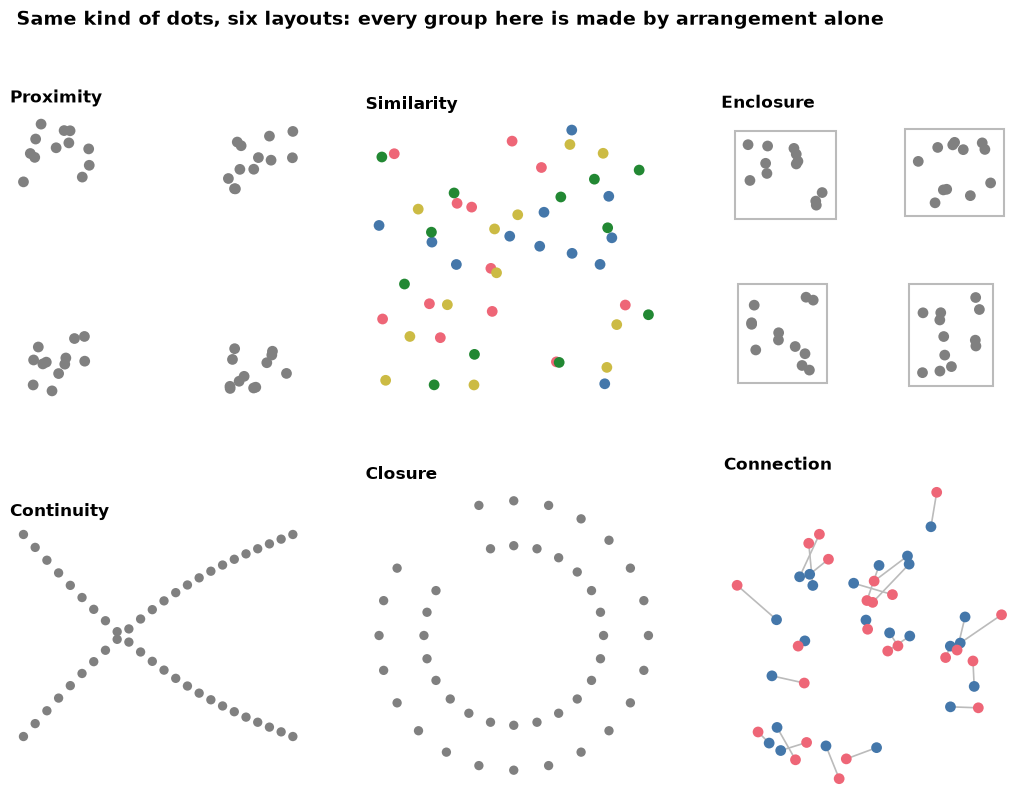

In [3]:
PANELS = ["proximity", "similarity", "enclosure", "continuity", "closure", "connection"]


def draw_panel(name, ax, lines=True):
    p = gest[gest.panel == name]
    if name == "enclosure":
        for _, g in p.groupby("group"):
            x0, x1 = g.x.min() - 0.4, g.x.max() + 0.4
            y0, y1 = g.y.min() - 0.4, g.y.max() + 0.4
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=GREY, lw=1.5))
    if name == "connection" and lines:
        for _, pair in p.groupby("connector"):
            ax.plot(pair.x, pair.y, color=GREY, lw=1.2, zorder=1)
    ax.scatter(p.x, p.y, s=p["size"], c=p.colour, linewidths=0, zorder=2)
    ax.set_aspect("equal")
    ax.axis("off")


fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, name in zip(axes.flat, PANELS):
    draw_panel(name, ax)
    ax.set_title(name.capitalize())

fig.suptitle("Same kind of dots, six layouts: every group here is made by arrangement alone",
             x=0.13, ha="left", fontsize=14, fontweight="bold")
save(fig, "t2_six_principles.png")

| Panel | What the eye does | True groups |
|---|---|---|
| Proximity | Empty space works as a border, so four clumps read as four groups. | 4 |
| Similarity | One mixed cloud with no spatial cue. The eye sorts the dots by hue alone. | 4 |
| Enclosure | The clumps are looser than in proximity. The boxes make the grouping clear. | 4 |
| Continuity | The eye follows the smoothest path through the crossing and sees two curves, not four arms meeting at a point. | 2 |
| Closure | Two rings, each with a gap. The brain fills the gaps and sees two whole circles. | 2 |
| Connection | 24 lines make 24 pairs, even though the partners differ in colour and often aren't each other's nearest dot. | 24 |

Two panels work because of what's *missing*. Closure has 44 dots, not 48, and the brain fills in the gaps.
Similarity has no spatial separation at all, so colour is the only cue. Pull the colours apart and it turns
into a proximity test.

## 2. Ask a real person

The reader sees each panel on its own, **without its title**, because the title would give the answer away.
For each one I ask "how many groups do you see?" and "what makes them a group?"

The connection panel is shown twice: **lines off first, then lines on**. That order means the reader can't
carry the pairs over from the version with lines. It also covers step 3.

In [4]:
from IPython.display import clear_output, display

RESULTS = Path("gestalt_results.csv")
# To run: set READER, flip RUN_EXPERIMENT to True and run this cell with the reader.
# Then flip it back to False and Restart & Run All.
RUN_EXPERIMENT = False
READER = "a classmate"

SHOW = [("proximity", True), ("similarity", True), ("enclosure", True), ("continuity", True),
        ("closure", True), ("connection", False), ("connection", True)]


def ask_count(prompt):
    while not (answer := input(prompt).strip()).isdigit():
        print("A whole number, please.")
    return int(answer)


def run_gestalt(reader):
    rows = []
    for i, (name, lines) in enumerate(SHOW, 1):
        clear_output(wait=True)
        print(f"Display {i} of {len(SHOW)}")
        fig, ax = plt.subplots(figsize=(5, 5))
        draw_panel(name, ax, lines=lines)
        display(fig)
        plt.close(fig)
        rows.append({
            "panel": name,
            "lines": lines,
            "perceived_groups": ask_count("How many groups do you see? "),
            "why": input("What makes them a group? (their words) ").strip(),
            "reader": reader,
        })
    clear_output()
    return pd.DataFrame(rows)


if RUN_EXPERIMENT:
    run_gestalt(READER).to_csv(RESULTS, index=False)

if RESULTS.exists():
    results = pd.read_csv(RESULTS)
    display(results)
else:
    results = None
    print("No gestalt_results.csv yet. Set RUN_EXPERIMENT = True and run this cell with your reader.")

No gestalt_results.csv yet. Set RUN_EXPERIMENT = True and run this cell with your reader.


In [5]:
if results is None:
    print("Waiting for gestalt_results.csv.")
else:
    table = results[results.lines].assign(
        principle=lambda d: d.panel.str.capitalize(),
        true_groups=lambda d: d.panel.map(TRUE_GROUPS),
    )
    table["match"] = np.where(table.perceived_groups == table.true_groups, "yes", "no")
    display(table[["panel", "principle", "true_groups", "perceived_groups", "match", "why"]])

Waiting for gestalt_results.csv.


## 3. Make the principles fight

In the connection panel, three principles disagree:

- **Similarity** says there are 2 groups: all the red dots and all the blue dots.
- **Proximity** says there are a few loose clumps, and partners often aren't neighbours.
- **Connection** says there are 24 pairs, each made of one red dot and one blue dot.

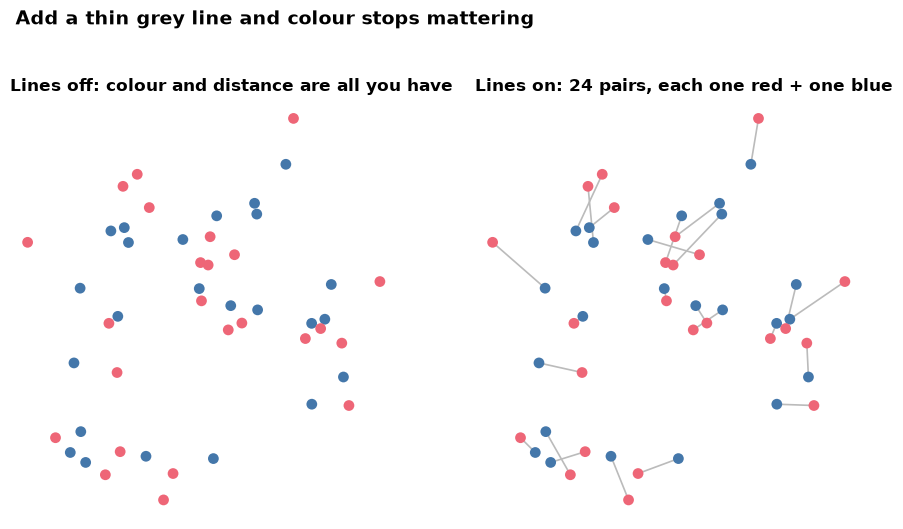

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
for ax, lines in zip(axes, [False, True]):
    draw_panel("connection", ax, lines=lines)
axes[0].set_title("Lines off: colour and distance are all you have")
axes[1].set_title("Lines on: 24 pairs, each one red + one blue")
fig.suptitle("Add a thin grey line and colour stops mattering", x=0.13, y=1.03, ha="left",
             fontsize=14, fontweight="bold")
save(fig, "t2_connection_fight.png")

In [7]:
def winner(n):
    if n >= 12:
        return "connection (pairs)"
    if n == 2:
        return "similarity (colour)"
    return "proximity / mixed"


if results is None:
    print("Waiting for gestalt_results.csv.")
else:
    for _, row in results[results.panel == "connection"].iterrows():
        label = "lines on " if row.lines else "lines off"
        print(f"{label}: {row.perceived_groups:>2} groups -> {winner(row.perceived_groups):<20} "
              f"they said: {row.why!r}")

Waiting for gestalt_results.csv.


**Expected:** with the lines off, the reader groups by colour (about 2 groups) or by clumps. With the lines
on, the answer jumps to about 24, and connection beats both similarity and proximity.

> **My reader's result** *(fill in from the two tables)*: who it was, which panels they counted correctly,
> and which principle won the fight. Where a count missed, say why in their words. If the lines didn't beat
> colour, say so too. One likely reason is that the thin grey lines are faint next to saturated red and
> blue.

## 4. Proximity in a real chart (`tips.csv`)

In [8]:
tips = pd.read_csv(DATA / "tips.csv")
DAYS = ["Thur", "Fri", "Sat", "Sun"]
counts = tips.groupby(["day", "smoker"]).size().unstack().reindex(DAYS)[["No", "Yes"]]
counts

smoker,No,Yes
day,,
Thur,45,17
Fri,4,15
Sat,45,42
Sun,57,19


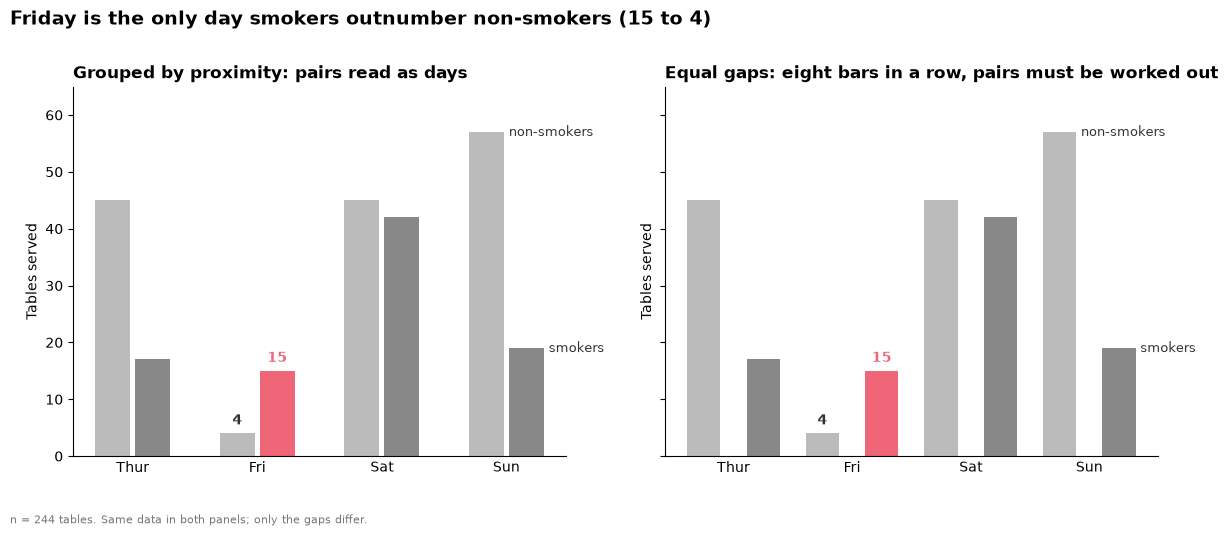

In [9]:
def grouped_bars(ax, inner_gap, outer_gap, width=0.35):
    """Two bars per day. The two gaps are the only thing that does the grouping."""
    step = 2 * width + inner_gap + outer_gap
    for i, day in enumerate(DAYS):
        left = i * step
        for j, smoker in enumerate(["No", "Yes"]):
            x = left + j * (width + inner_gap)
            n = counts.loc[day, smoker]
            if day == "Fri" and smoker == "Yes":
                colour = RED
            else:
                colour = "#888888" if smoker == "Yes" else GREY
            ax.bar(x, n, width, align="edge", color=colour)
            if day == "Fri":
                ax.text(x + width / 2, n + 1, str(n), ha="center", va="bottom",
                        color=RED if smoker == "Yes" else INK, fontweight="bold")
            if day == "Sun":
                ax.text(x + width + 0.05, n, "non-smokers" if smoker == "No" else "smokers",
                        va="center", color=INK, fontsize=9)
    ax.set_xticks([i * step + width + inner_gap / 2 for i in range(len(DAYS))], DAYS)
    ax.tick_params(axis="x", length=0)
    ax.set_ylabel("Tables served")
    ax.set_ylim(0, 65)


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
grouped_bars(axes[0], inner_gap=0.05, outer_gap=0.5)
grouped_bars(axes[1], inner_gap=0.275, outer_gap=0.275)
axes[0].set_title("Grouped by proximity: pairs read as days")
axes[1].set_title("Equal gaps: eight bars in a row, pairs must be worked out")
fig.suptitle("Friday is the only day smokers outnumber non-smokers (15 to 4)",
             x=0.08, y=1.04, ha="left", fontsize=14, fontweight="bold")
fig.text(0.08, -0.03, "n = 244 tables. Same data in both panels; only the gaps differ.",
         fontsize=8, color="#777777")
save(fig, "t2_proximity_tips.png")

**Principle used: proximity.** On the left, the gap inside each pair is a tenth of the gap between pairs, so
the eye reads four day-groups before it reads anything else.

**What the right panel loses.** The data and the bars are the same. Only the spacing changed. With equal
gaps the eye sees one row of eight bars, and nothing in the picture says which two belong together. The
reader has to use the tick labels to work out the pairs, one bar at a time. That turns a preattentive
grouping into serial work. "Is Friday different?" now needs reading where before it only needed seeing.

Colour does one job here: the one red bar is the finding. Smokers and non-smokers are labelled directly on
Sunday's pair, so the chart doesn't rely on colour alone and needs no legend.

## 5. Where each principle already lives

- **Proximity.** In a grouped bar chart, bars in the same category sit tight together and the bigger gap
  separates the groups.
- **Similarity.** In a multi-line chart, every point drawn in the same colour reads as one series, wherever
  it sits.
- **Enclosure.** A shaded recession band behind a time series turns the years inside the grey rectangle into
  one unit.
- **Closure.** A chart with only left and bottom axes still reads as a closed plot area. The eye fills in the
  missing top and right sides.
- **Continuity.** When two lines cross in a line chart, the eye follows each one smoothly through the
  crossing instead of swapping between them.
- **Connection.** In a dumbbell or slope chart, the line between "before" and "after" is the only thing that
  tells you which two dots belong together.

## The question: legend vs direct labels

A legend makes the reader repeat a lookup loop. They see a colour, look away to the legend, find the match,
**hold** "grey = non-smokers" in working memory, look back and find the bar again. Every series costs one
memory slot and two eye jumps. Working memory holds about 4 ± 1 items, so a five-entry legend uses all of it
before the reader has thought about the data at all.

Direct labels use **proximity**. The label sits next to the thing it names, so the eye links them
automatically, without help from memory. The reader holds nothing in memory and does no lookups. The job
moves from working memory, which is small and slow, to perception, which is fast and parallel. That's
cheaper for the brain, and it's why the tips chart above has no legend.